In [167]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sessions = []
with open("sessions.jsonl") as f:
    for line in f:
        line = line.strip()
        if line:
            sessions.append(json.loads(line))

# sessions — список списков целых чисел
print(f"Всего сессий: {len(sessions)}")
print(f"Первая сессия: {sessions[0]}")

len_sessions = [] # список длин сессий
objects = {} # частотный словарь товаров (id товара - количество обращений)

for s in sessions:
  len_sessions.append(len(s))
  for obj in s:
    if obj in objects:
      objects[obj] += 1
    else:
      objects[obj] = 1

min_len = min(len_sessions)
max_len = max(len_sessions)
mean_len = np.mean(len_sessions)
print(f"Минимальная длина сессии: {min_len}")
print(f"Максимальная длина сессии: {max_len}")
print(f"Средняя длина сессии: {round(mean_len, 2)}")
print()
print(f"Уникальных товаров: {len(objects)}")

obj_arr = np.array([[i, objects[i]] for i in objects])
cols = ["product", "popularity"]
df = pd.DataFrame(data=obj_arr, columns=cols)
df.head()

Всего сессий: 2565
Первая сессия: [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341, 293]
Минимальная длина сессии: 3
Максимальная длина сессии: 20
Средняя длина сессии: 10.47

Уникальных товаров: 400


,product,popularity
0,380,571
1,293,736
2,262,92
3,114,1067
4,123,38


In [168]:
min_popular = df['popularity'].min()
max_popular = df['popularity'].max()
mean_popular = df['popularity'].mean()
print()

print(df.sort_values('popularity'))
print(f"Среднее значение популярности товара: {df['popularity'].mean()}")
print()

filter_max_popularity = df['popularity'] == max_popular
filter_min_popularity = df['popularity'] == min_popular
print("Наиболее популярный(ые) товар(ы):")
print(df[filter_max_popularity])
print()
print("Наименее популярный(ые) товар(ы):")
print(df[filter_min_popularity])


     product  popularity
388      184           5
399      305           5
361      118           6
80       326           6
357      291           7
..       ...         ...
13       260         833
3        114        1067
15        53        1223
6        335        1691
16        54        2914

[400 rows x 2 columns]
Среднее значение популярности товара: 67.1075

Наиболее популярный(ые) товар(ы):
    product  popularity
16       54        2914

Наименее популярный(ые) товар(ы):
     product  popularity
388      184           5
399      305           5


In [169]:
number_of_products = len(objects)

# исследуем плотность ориентированного графа
edges = set() # множество всех ребер
for s in sessions:
  for i in range(1, len(s)):
    a = s[i-1] # начало перехода
    b = s[i] # конец перехода
    edges.add((a, b))
edges_number = len(edges)

# количество ребер в полном ориентированном графе
# (между любыми двумя вершинами проходит по два ориентированных ребра)
edges_in_theory = number_of_products * (number_of_products - 1)

graph_density = round(edges_number / edges_in_theory, 4) * 100
print(f"Плотность покрытия графа: {graph_density}%")

Плотность покрытия графа: 5.84%


Так как плотность покрытия графа мала, его рациональнее хранить
списком смежности для каждой вершины, а не матрицей связности.

Text(5.069444444444445, 0.5, 'Количество сессий')

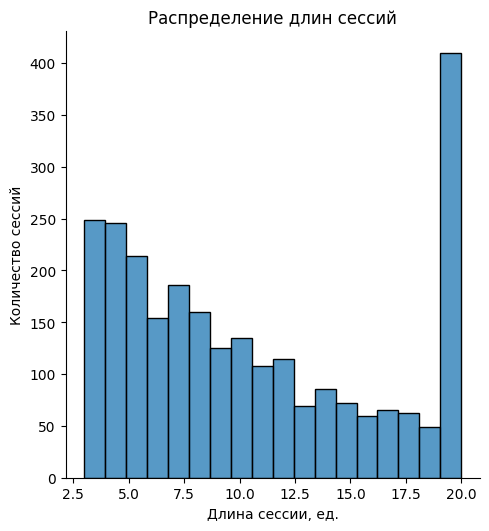

In [170]:
# распределение длин сессий
sns.displot(data=np.array(len_sessions), bins=max_len - min_len + 1)
plt.title('Распределение длин сессий')
plt.xlabel('Длина сессии, ед.')
plt.ylabel('Количество сессий')

Text(0, 0.5, 'Популярность')

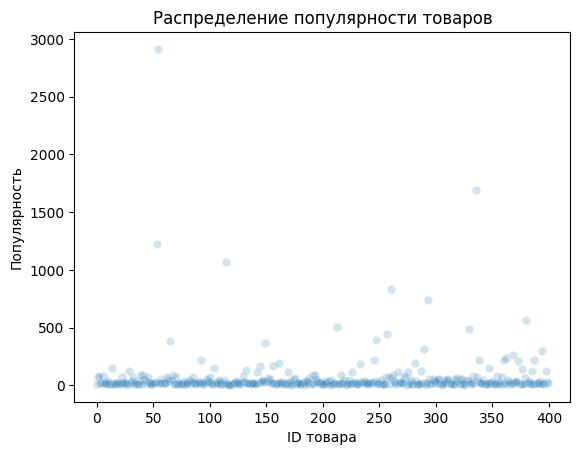

In [171]:
# распределение популярности товаров
sns.scatterplot(data=df, x='product', y='popularity', alpha=0.2)
plt.title("Распределение популярности товаров")
plt.xlabel('ID товара')
plt.ylabel('Популярность')

Как можно видеть из графика выше, товары с популярностью > 500
составляют малую часть набора. Построим распределение, которое
их не учитывает:

Text(0, 0.5, 'Популярность')

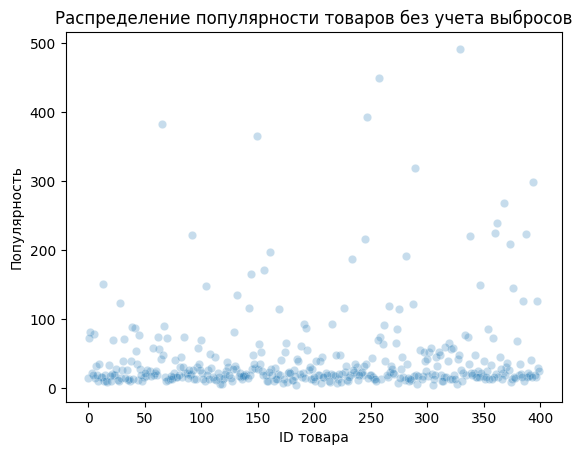

In [172]:
sns.scatterplot(data=df[df['popularity'] < 500], x='product', y='popularity', alpha=0.25)
plt.title("Распределение популярности товаров без учета выбросов")
plt.xlabel('ID товара')
plt.ylabel('Популярность')

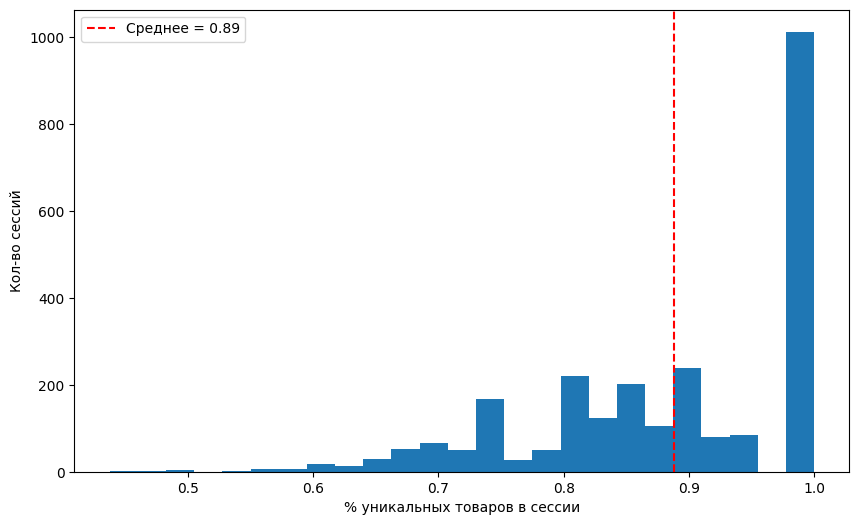

In [173]:
# распределение количества уникальных товаров в сессиях
percentage = [len(set(i)) / len(i) for i in sessions]

plt.figure(figsize=(10, 6))
plt.hist(percentage, bins=25)
plt.xlabel('% уникальных товаров в сессии')
plt.ylabel('Кол-во сессий')
plt.axvline(x=np.mean(percentage), color='r', linestyle='--',
            label=f'Среднее = {np.mean(percentage):.2f}')
plt.legend()

In [174]:
def train_test_split(
    sessions: list[list[int]],
) -> tuple[list[list[int]], list[int]]:
    """
    Разбиение сессий на train и test.

    Для каждой сессии:
      - все товары, кроме последнего, становятся
        обучающей сессией
      - последний товар становится тестовой целью

    Возвращаемые списки выровнены по индексу:
    test_targets[i] — товар, который нужно
    предсказать по train_sessions[i] как истории.

    Parameters
    ----------
    sessions : list of lists of ints
        Каждый вложенный список — одна сессия ID
        товаров, упорядоченная по времени.
        Все сессии содержат не менее 3 товаров.

    Returns
    -------
    train_sessions : list of lists of ints
        Сессии для обучения (исходные без последнего товара).
    test_targets : list of ints
        Следующий товар для предсказания по каждой сессии.
    """
    train_sessions = [session[:-1] for session in sessions]
    test_targets = [session[-1] for session in sessions]
    return train_sessions, test_targets

In [175]:
train, test = train_test_split(sessions)

In [176]:
def create_adjacency_list(
    train: list[list[int]]
    ) -> dict[int, dict[int, int]]:
    """
    Создание списка связности ориентированного графа товаров.
    Учитывает ориентацию ребер и кратность ребер.

    Parameters
    ----------
    train: list of lists of ints
      Каждый вложенный список - одна сессия, содержащая не менее двух товаров.

    Returns
    -------
    adj: dictionary
      Ключ - номер товара i, значение - словарь смежных с ним вершин
      в ориентированном кратном графе. Ключ вложенного словаря - номер
      смежной вершины j, значение - количество ребер ij.

    """
    adj = {}
    for t in train:
      for i in range(1, len(t)):
        a = t[i-1] # начало перехода
        b = t[i] # конец перехода
        if a in adj:
          if b in adj[a]:
            adj[a][b] += 1
          else:
            adj[a][b] = 1
        else:
          temp_dict = {b: 1}
          adj[a] = temp_dict
    return adj

In [177]:
adj_list = create_adjacency_list(train)
'''for i in adj_list:
  print(i, end= ': ')
  print(adj_list[i])'''

"for i in adj_list:\n  print(i, end= ': ')\n  print(adj_list[i])"

In [178]:
def create_probability_matrix(
    adj: dict[int, dict[int, int]]
) -> dict[int, dict[int, float]]:
    """
    Вычисление вероятности посещения вершины j сразу после вершины i
    (P(j|i)).

    Parameters
    ----------
    adj: dictionary
      Ключ - номер товара i, значение - словарь смежных с ним вершин
      в ориентированном кратном графе. Ключ вложенного словаря - номер
      смежной вершины j, значение - количество ребер ij.

    Returns
    -------
    p: dictionary
      Ключ - номер товара i, значение - словарь смежных с ним вершин
      в ориентированном кратном графе. Ключ вложенного словаря - номер
      смежной вершины j, значение - вероятность перехода ij P(j|i).
    """
    p = {}
    for i in adj:
      vertex_degree = 0 # степень вершины = количество всех переходов из i
      temp_dict = {}
      for j in adj[i]:
        vertex_degree += adj[i][j]
      for j in adj[i]:
        temp_dict[j] = adj[i][j] / vertex_degree
      p[i] = temp_dict
    return p

In [179]:
probs = create_probability_matrix(adj_list)
'''for i in probs:
  print(i, end= ': ')
  print(probs[i])'''

"for i in probs:\n  print(i, end= ': ')\n  print(probs[i])"

In [180]:
def candidate_tops(
    p: dict[int, dict[int, float]]
) -> dict[int, list[int]]:
    """
    Вычисление для каждого продукта из train топ-10 кандидатов,
    отсортированных по убыванию вероятности перехода.
    Если кандидатов с ненулевой вероятностью перехода меньше десяти,
      возвращается список меньшего размера.

    Parameters
    ----------
    p: dictionary
      Ключ - номер товара i, значение - словарь смежных с ним вершин
      в ориентированном кратном графе. Ключ вложенного словаря - номер
      смежной вершины j, значение - вероятность перехода ij P(j|i).

    Returns
    -------
    tops: dictionary
      Ключ - номер товара i, значение - список с топ-10 (или меньше)
      наиболее вероятных переходов из него.
    """
    tops = {}
    for i in p:
      sort_arr = [] # массив пар "вероятность - id товара"
      for j in p[i]:
        sort_arr.append([p[i][j], j])
      sort_arr.sort()
      sort_arr.reverse()
      one_top = sort_arr[:10]
      one_result_top = [i[1] for i in one_top]
      tops[i] = one_result_top
    return tops

In [181]:
all_tops = candidate_tops(probs)
'''for i in all_tops:
  print(i, end=': ')
  print(all_tops[i])'''

"for i in all_tops:\n  print(i, end=': ')\n  print(all_tops[i])"

In [182]:
def model(
    tops: dict[int, list[int]],
    sessions: list[list[int]]
) -> list[list[int]]:
    """
    Возвращение для последнего товара в сессии соответствующего топа
    кандидатов на переход.

    Parameters
    ----------
    tops: list of lists of ints
      Двумерный массив топов кандидатов на переход.
    sessions: list of lists of ints
        Каждый вложенный список — одна сессия ID
        товаров, упорядоченная по времени.
        Все сессии содержат не менее 2 товаров.

    Returns
    -------
    results: двумерный массив. Каждый сложенный список - топ для
    соответствующего товара во входных данных.
    """
    results = []
    for s in sessions:
      product = s[-1]
      if not product in tops:
        results.append([])
      else:
        results.append(tops[product])
    return results

In [183]:
test_results = model(all_tops, train)
'''for i in test_results:
  print(i)'''

'for i in test_results:\n  print(i)'

In [184]:
def hit_at_k(
    recommendations: list[list[int]],
    true_items: list[int],
    k: int = 10,
) -> float:
    """
    Вычисление Hit@K для списка предсказаний.

    Parameters
    ----------
    recommendations : list of lists of ints
        recommendations[i] — ранжированный список
        рекомендаций для i-го примера.
    true_items : list of ints
        true_items[i] — истинный следующий товар
        для i-го примера.
    k : int
        Отсечка top-K (по умолчанию 10).

    Returns
    -------
    float
        Hit@K, значение от 0 до 1.
    """
    assert len(recommendations) == len(true_items), \
        "recommendations и true_items должны совпадать по длине"

    hits = 0
    for recs, true_item in zip(recommendations, true_items):
        if true_item in recs[:k]:
            hits += 1

    return hits / len(true_items)

In [185]:
result_1 = hit_at_k(test_results, test)
print(f"Значение метрики Hit@10 для сложной модели: {result_1}")

Значение метрики Hit@10 для сложной модели: 0.5044834307992203


In [186]:
def baseline_model(
    train: list[list[int]]
) -> list[int]:
    """
    Возвращение топ-10 самых популярных за все сессии товаров.

    Parameters
    ----------
    train: list of lists of ints
      Каждый вложенный список — одна сессия ID
        товаров, упорядоченная по времени.
        Все сессии содержат не менее 2 товаров.

    Returns
    -------
    results: list of ints.
      Список - топ-10 (или меньше) самых популярных товаров.
    """
    count_popularity = {} # частотный словарь товаров
    sort_array = []
    for s in train:
      for product in s:
        if not product in count_popularity:
          count_popularity[product] = 1
        else:
          count_popularity[product] = 1
    for i in count_popularity:
      sort_array.append([count_popularity[i], i])
    sort_array.sort()
    sort_array.reverse()
    arr = sort_array[:10]
    result = [i[1] for i in arr]
    return result

In [187]:
baseline_top = baseline_model(train)
# топ-10 одинаков для всех сессий
baseline_test = [baseline_top] * len(sessions)
result_2 = hit_at_k(baseline_test, test)
print(f"Значение метрики Hit@10 для бейзлайн-модели: {result_2}")

Значение метрики Hit@10 для бейзлайн-модели: 0.01949317738791423


In [188]:
if result_1 > result_2:
  print(f"Сложная модель обошла безлайн ({result_1} > {result_2})")
else:
  print(f"Сложная модель не обошла безлайн ({result_1} < {result_2})")

Сложная модель обошла безлайн (0.5044834307992203 > 0.01949317738791423)


Модель значительно обошла безлайн - следовательно, в переходах между товарами есть закономерности, и сложная модель, выявляющая их, работает эффективнее простой.